# Visualization of result run on MIB

In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import numpy as np

# Set the theme for all plots
sns.set_theme(style="whitegrid")
colors = {"CPR": "steelblue", "CMD": "orange"}

### Plots

In [3]:
def plot_faithfulness_area(data_dict, method_name, color, evaluated_edges=None, save=False):
    """
    Plots the faithfulness area curve for a given method (CPR or CMD)
    and saves it to a file.
    
    Args:
        data_dict (dict): The dictionary for either CPR or CMD.
        method_name (str): The name of the method ("CPR" or "CMD").
        color (str): The base color for the plot.
    """
    total_edges = data_dict['weighted_edge_counts'][-1]
    filename = f'faithfulness_vs_edges_{method_name.lower()}.png'
    
    # Create percentage-based x-axis and y-axis
    x_data = [e / total_edges for e in data_dict['weighted_edge_counts']]
    y_data = np.array(data_dict['faithfulnesses']) # Use numpy array
    
    # Create an array of '1's for comparison
    y_one = np.ones_like(y_data)

    # Create the plot
    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    # Plot main faithfulness line and area
    ax.plot(x_data, y_data, label=f'{method_name} Faithfulness', color=color, marker='o', markersize=5, zorder=5)
    ax.fill_between(x_data, y_data, color=color, alpha=0.3, label=f'{method_name} Area Under Curve')

    # Add the reference grid line at y=1
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, zorder=4, label='Faithfulness = 1.0')
                        
    if method_name == "CMD":
        # 2. if CMD plot in red the area between the 1-line and the faithfulnesses line
        # This is functionally the same as the CPR condition, as CMD is always <= 1
        # Linear interpolation using the next value (step-wise fill)
        for i in range(len(x_data) - 1):
            # Only fill if y_data[i] <= 1
            if y_data[i] <= 1:
                ax.fill_between(
                    [x_data[i], x_data[i+1]],
                    [y_data[i], y_data[i+1]],
                    [1, 1],
                    color='#961212', alpha=0.5, interpolate=False,
                    label='Area (1 - Faithfulness)' if i == 0 else None,
                    linewidth=0, edgecolor=None
                )
            elif y_data[i] > 1:
                ax.fill_between(
                    [x_data[i], x_data[i+1]],
                    [1, 1],
                    [y_data[i], y_data[i+1]],
                    color='#961212', alpha=0.5, interpolate=False,
                    label='Area (Faithfulness - 1)' if i == 0 else None,
                    linewidth=0, edgecolor=None
                )

    # Plot a vertical line at the maximum circuit size
    if evaluated_edges:
        max_percentage = evaluated_edges / total_edges
        ax.axvline(x=max_percentage, color='gray', linestyle='--', linewidth=1.0, zorder=3, label='Max Evaluated Circuit Size')
    
    
    # Customize grid
    ax.grid(True, which='major', linestyle=':', linewidth=0.5)
    ax.set_axisbelow(True)

    # Format x-axis as percentages
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_xlim(x_data[0], 1)
    ax.set_ylim(bottom=0) # Ensure y-axis starts at 0

    # Set labels and title
    # ax.set_title(f'{method_name} Faithfulness vs. Percentage of Total Edges', fontsize=15, fontweight='bold')
    ax.set_xlabel('Percentage of Total Weighted Edges Included', fontsize=15)
    ax.set_ylabel('Faithfulness', fontsize=15)

    # Add legend
    ax.legend(loc='upper left', frameon=True)
    
    # Scale
    ax.set_yscale('linear')
    ax.set_xscale('log')

    plt.tight_layout()
    if save:
        plt.savefig(filename, dpi=300)
    plt.show()

def plot_CMD_and_CPR(data, colors):
    """
    Plots Faithfulness vs. Percentage of Total Edges for CPR and CMD.
    Skips the first element (0%) to avoid log scale issues.
    """
    x_cpr = [x  / data['CPR']['weighted_edge_counts'][-1] for x in data['CPR']['weighted_edge_counts']]
    y_cpr = data['CPR']['faithfulnesses']
    x_cmd = [x  / data['CMD']['weighted_edge_counts'][-1] for x in data['CMD']['weighted_edge_counts']]
    y_cmd = data['CMD']['faithfulnesses']

    # Skip the first element (0%) for log scale
    x_cpr_plot, y_cpr_plot = x_cpr[1:], y_cpr[1:]
    x_cmd_plot, y_cmd_plot = x_cmd[1:], y_cmd[1:]

    plt.figure(figsize=(8, 5))
    ax = plt.gca()

    # Plot CPR
    ax.plot(x_cpr_plot, y_cpr_plot, label='CPR Faithfulness', color=colors['CPR'], marker='o', markersize=5, zorder=5)
    ax.fill_between(x_cpr_plot, y_cpr_plot, color=colors['CPR'], alpha=0.3)

    # Plot CMD
    ax.plot(x_cmd_plot, y_cmd_plot, label='CMD Faithfulness', color=colors['CMD'], marker='o', markersize=5, zorder=5)
    ax.fill_between(x_cmd_plot, y_cmd_plot, color=colors['CMD'], alpha=0.3)
    
    # Add the vertical line at the maximum circuit size CMD
    max_evaluated_edges = data['edges']
    max_percentage = max_evaluated_edges / data['CPR']['weighted_edge_counts'][-1]
    ax.axvline(x=max_percentage, color='orange', linestyle='--', linewidth=1.0, zorder=3, label='CMD: Max Evaluated Circuit Size')

    # Add the vertical line at the maximum circuit size CPR
    max_evaluated_edges = data['positive_edges']
    max_percentage = max_evaluated_edges / data['CPR']['weighted_edge_counts'][-1]
    ax.axvline(x=max_percentage, color='steelblue', linestyle='--', linewidth=1.0, zorder=3, label='CPR: Max Evaluated Circuit Size')

    # Add the required stronger grid line at y=1
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, zorder=4, label='Faithfulness = 1.0')

    # Customize grid
    ax.grid(True, which='major', linestyle=':', linewidth=0.5)
    ax.set_axisbelow(True)

    # Format x-axis as percentages
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax.set_xlim(min(x_cpr_plot[0], x_cmd_plot[0]), 1)
    ax.set_ylim(bottom=0) # Ensure y-axis starts at 0

    # Set labels and title
    # ax.set_title('Faithfulness vs. Percentage of Total Edges (CPR vs. CMD)', fontsize=15, fontweight='bold')
    ax.set_xlabel('Percentage of Total Weighted Edges Included', fontsize=15)
    ax.set_ylabel('Faithfulness', fontsize=15)

    # Set scale
    ax.set_yscale('linear')
    ax.set_xscale('log')

    # Add legend
    ax.legend(loc='upper left', frameon=True)

    plt.tight_layout()
    plt.show()

In [4]:
import pandas as pd

def plot_aggregate_metrics_bar(data, colors):
    """
    Plots a bar chart comparing aggregate faithfulness metrics for CPR and CMD.

    Args:
        data (dict): Dictionary containing 'CPR' and 'CMD' results.
        colors (dict): Dictionary mapping method names to colors.
    """
    metrics_data = [
        {'Method': 'CPR', 'Metric': 'Area Under', 'Value': data['CPR']['area_under']},
        {'Method': 'CPR', 'Metric': 'Area From 1', 'Value': data['CPR']['area_from_1']},
        {'Method': 'CMD', 'Metric': 'Area Under', 'Value': data['CMD']['area_under']},
        {'Method': 'CMD', 'Metric': 'Area From 1', 'Value': data['CMD']['area_from_1']},
    ]
    metrics_df = pd.DataFrame(metrics_data)

    plt.figure(figsize=(10, 6))
    barplot = sns.barplot(
        data=metrics_df,
        x='Metric',
        y='Value',
        hue='Method',
        palette=[colors['CPR'], colors['CMD']]
    )

    for p in barplot.patches:
        barplot.annotate(format(p.get_height(), '.3f'), 
                         (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', 
                         xytext=(0, 9), 
                         textcoords='offset points')

    # plt.title('Comparison of Aggregate Faithfulness Metrics', fontsize=15, fontweight='bold')
    plt.xlabel('Aggregate Metric', fontsize=15)
    plt.ylabel('Value', fontsize=12)
    plt.legend(title='Method')
    plt.tight_layout()
    plt.show()

### GPT2 Small CF (IE)

In [5]:
MODEL = "qwen"
TASK = "ioi"
METHOD = "PAP"
PATCHING = "counterfactual"

In [6]:
data = json.load(open(f"results/{METHOD}/{PATCHING}/{MODEL}-{TASK}/results.json"))

In [7]:
edges_scores = json.load(open(f"results/{METHOD}/{PATCHING}/{MODEL}-{TASK}/scores.json"))
positive_scores = 0
for dict_score in edges_scores['edges'].values():
    if dict_score['score'] > 0:
        positive_scores += 1
data["positive_edges"] = positive_scores
print(f"Evaluated: {data['edges']} edges, {data['positive_edges']} positive edges out of {int(data['CPR']['weighted_edge_counts'][-1])} total edges")

Evaluated: 5046 edges, 2932 positive edges out of 179749 total edges


#### CMD and CPR

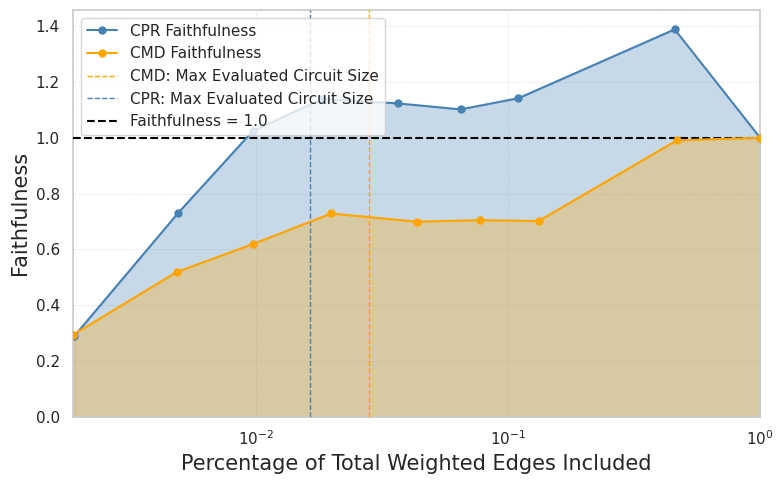

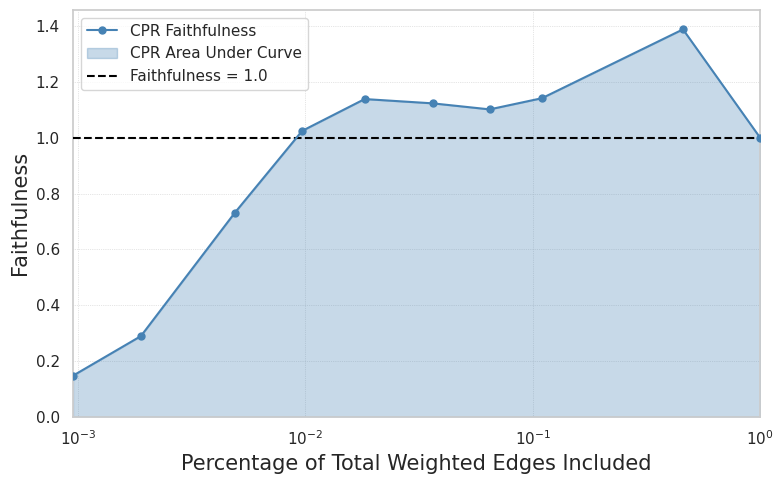

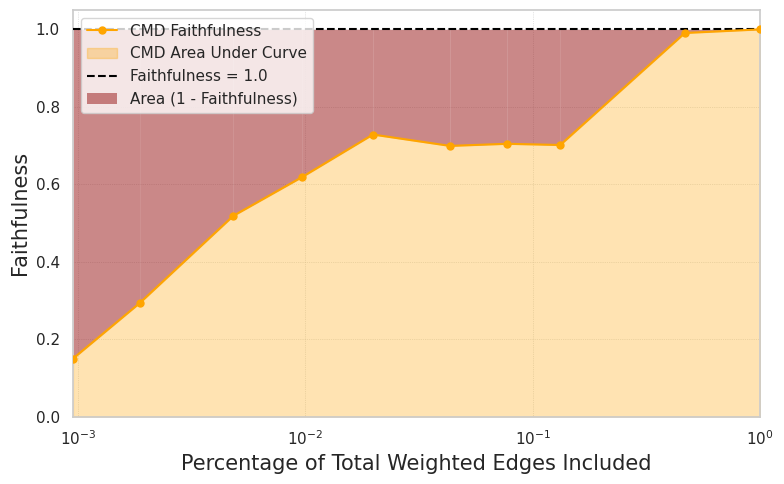

In [9]:
plot_CMD_and_CPR(data, colors)
plot_faithfulness_area(data["CPR"], "CPR", colors['CPR'])
plot_faithfulness_area(data["CMD"], "CMD", colors['CMD'])